# Math4AI Capstone — Data Inspection Notebook

**Purpose:** Verify all three datasets are present and correctly shaped, understand class distributions,
visualize the data geometrically, and record statistics before writing any model code.

**Datasets inspected:**
1. `linear_gaussian.npz` — Two linearly separable Gaussian blobs (binary, 2D)
2. `moons.npz` — Two interleaved moon shapes (binary, 2D, nonlinear boundary)
3. `digits_data.npz` + `digits_split_indices.npz` — Handwritten digit images (10-class, 64D)

**Allowed libraries:** NumPy, Matplotlib only (per capstone rules).

Run each cell top-to-bottom from the project root directory:
```
cd math4ai_capstone
jupyter notebook starter_pack/src/inspect_data.ipynb
```

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Use a clean style for all plots
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Helper: print a horizontal separator
def section(title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

print("Imports OK. NumPy version:", np.__version__)

Imports OK. NumPy version: 2.2.6


---
## 1. Linear Gaussian Dataset

Two Gaussian blobs with mild class overlap. This task is **well-matched to a linear decision boundary**
because each class is drawn from a multivariate Gaussian with the same covariance matrix —
the optimal Bayes classifier in this case is linear (Linear Discriminant Analysis).

In [15]:
# ── Load ──────────────────────────────────────────────────────────────────────
g = np.load("..\data\linear_gaussian.npz")

X_tr_g, y_tr_g = g['X_train'], g['y_train']
X_val_g, y_val_g = g['X_val'],   g['y_val']
X_te_g,  y_te_g  = g['X_test'],  g['y_test']

section("LINEAR GAUSSIAN — Shapes")
print(f"  Keys in file : {list(g.files)}")
print(f"  X_train      : {X_tr_g.shape}   (n_samples, n_features)")
print(f"  y_train      : {y_tr_g.shape}")
print(f"  X_val        : {X_val_g.shape}")
print(f"  X_test       : {X_te_g.shape}")
print(f"  Total samples: {len(y_tr_g)+len(y_val_g)+len(y_te_g)}")
print(f"  Feature dim  : {X_tr_g.shape[1]}  (2D → can plot directly)")
print(f"  Classes      : {np.unique(y_tr_g).tolist()}")

section("LINEAR GAUSSIAN — Class Distribution")
for split_name, y_split in [("train", y_tr_g), ("val", y_val_g), ("test", y_te_g)]:
    counts = {c: int((y_split == c).sum()) for c in np.unique(y_split)}
    print(f"  {split_name:5s}: {counts}  (total={len(y_split)})")

section("LINEAR GAUSSIAN — Feature Statistics (train set)")
print(f"  Feature 0 — mean={X_tr_g[:,0].mean():.3f}, std={X_tr_g[:,0].std():.3f}, "
      f"min={X_tr_g[:,0].min():.3f}, max={X_tr_g[:,0].max():.3f}")
print(f"  Feature 1 — mean={X_tr_g[:,1].mean():.3f}, std={X_tr_g[:,1].std():.3f}, "
      f"min={X_tr_g[:,1].min():.3f}, max={X_tr_g[:,1].max():.3f}")

# Per-class means (useful to see how separated the blobs are)
print("\n  Per-class feature means (train):")
for c in np.unique(y_tr_g):
    m = X_tr_g[y_tr_g == c].mean(axis=0)
    print(f"    class {c}: μ = [{m[0]:.3f}, {m[1]:.3f}]")


  LINEAR GAUSSIAN — Shapes
  Keys in file : ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
  X_train      : (240, 2)   (n_samples, n_features)
  y_train      : (240,)
  X_val        : (80, 2)
  X_test       : (80, 2)
  Total samples: 400
  Feature dim  : 2  (2D → can plot directly)
  Classes      : [0, 1]

  LINEAR GAUSSIAN — Class Distribution
  train: {np.int64(0): 120, np.int64(1): 120}  (total=240)
  val  : {np.int64(0): 40, np.int64(1): 40}  (total=80)
  test : {np.int64(0): 40, np.int64(1): 40}  (total=80)

  LINEAR GAUSSIAN — Feature Statistics (train set)
  Feature 0 — mean=0.080, std=1.365, min=-3.389, max=3.042
  Feature 1 — mean=-0.008, std=1.072, min=-2.786, max=3.047

  Per-class feature means (train):
    class 0: μ = [-0.969, -0.719]
    class 1: μ = [1.129, 0.703]


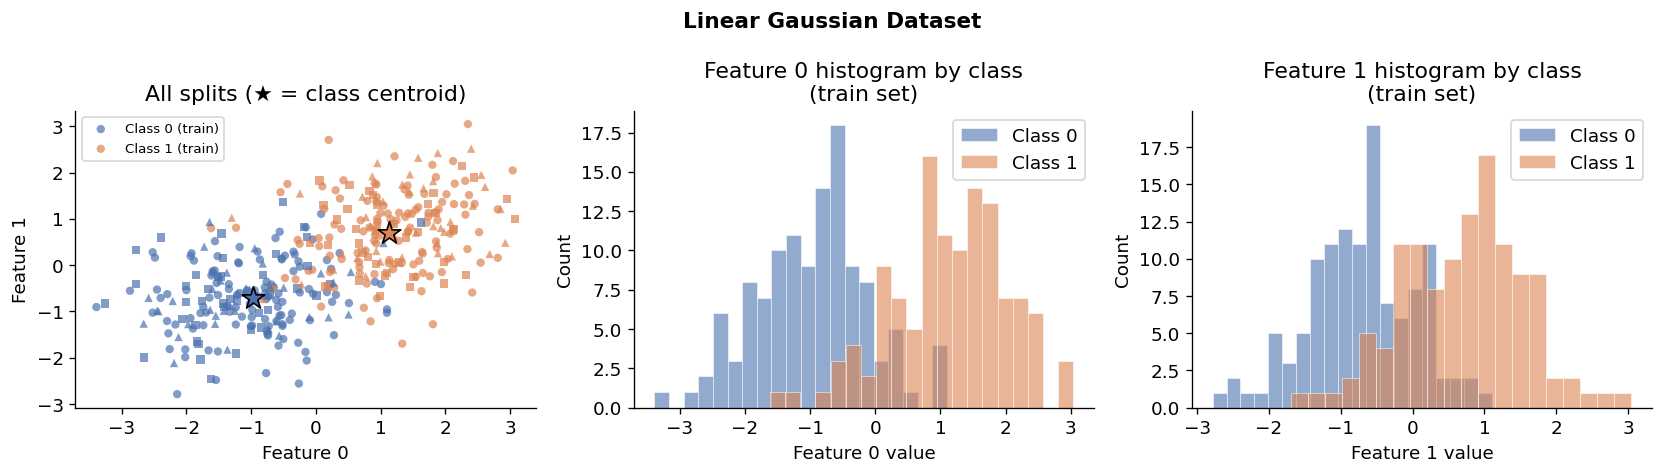

In [16]:
# ── Visualise Linear Gaussian ─────────────────────────────────────────────────
colors = ['#4C72B0', '#DD8452']   # blue for class 0, orange for class 1
labels = ['Class 0', 'Class 1']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Linear Gaussian Dataset", fontsize=13, fontweight='bold')

# ── Panel 1: All splits scatter ────────────────────────────────────────────
ax = axes[0]
for split_X, split_y, marker, alpha, label_suffix in [
    (X_tr_g, y_tr_g, 'o', 0.7, 'train'),
    (X_val_g, y_val_g, 's', 0.7, 'val'),
    (X_te_g, y_te_g, '^', 0.7, 'test'),
]:
    for c in [0, 1]:
        mask = split_y == c
        ax.scatter(split_X[mask, 0], split_X[mask, 1],
                   color=colors[c], marker=marker, alpha=alpha, s=25,
                   label=f"{labels[c]} ({label_suffix})" if label_suffix == 'train' else None,
                   edgecolors='none')
# Overlay class centroids
for c in [0, 1]:
    m = X_tr_g[y_tr_g == c].mean(axis=0)
    ax.scatter(*m, color=colors[c], s=200, marker='*', edgecolors='black', zorder=5)
ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')
ax.set_title('All splits (★ = class centroid)')
ax.legend(fontsize=8)

# ── Panel 2: Feature 0 distribution per class ──────────────────────────────
ax = axes[1]
for c in [0, 1]:
    ax.hist(X_tr_g[y_tr_g == c, 0], bins=20, alpha=0.6,
            color=colors[c], label=labels[c], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature 0 value'); ax.set_ylabel('Count')
ax.set_title('Feature 0 histogram by class\n(train set)')
ax.legend()

# ── Panel 3: Feature 1 distribution per class ──────────────────────────────
ax = axes[2]
for c in [0, 1]:
    ax.hist(X_tr_g[y_tr_g == c, 1], bins=20, alpha=0.6,
            color=colors[c], label=labels[c], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature 1 value'); ax.set_ylabel('Count')
ax.set_title('Feature 1 histogram by class\n(train set)')
ax.legend()

plt.tight_layout()
#plt.savefig('../figures/data_inspect_figures/inspect_gaussian.png', bbox_inches='tight')
plt.show()
#print("Saved → starter_pack/figures/data_inspect_figures/inspect_gaussian.png")

**Observation:** The two Gaussian blobs are well-separated along both feature axes with mild overlap.
The per-class histograms confirm that the class means differ significantly relative to within-class spread,
which is exactly the condition under which a **linear classifier will perform well** (LDA optimality).

→ We should **not** expect the neural network to significantly outperform softmax regression here.

---
## 2. Moons Dataset

Two interleaved crescent ('moon') shapes. This task **requires a nonlinear decision boundary** — no
affine hyperplane can correctly separate the two classes. This is where the one-hidden-layer network
should demonstrate a clear advantage over softmax regression.

In [17]:
# ── Load ──────────────────────────────────────────────────────────────────────
m = np.load("../data/moons.npz")

X_tr_m, y_tr_m = m['X_train'], m['y_train']
X_val_m, y_val_m = m['X_val'],   m['y_val']
X_te_m,  y_te_m  = m['X_test'],  m['y_test']

section("MOONS — Shapes")
print(f"  X_train      : {X_tr_m.shape}")
print(f"  X_val        : {X_val_m.shape}")
print(f"  X_test       : {X_te_m.shape}")
print(f"  Total samples: {len(y_tr_m)+len(y_val_m)+len(y_te_m)}")

section("MOONS — Class Distribution")
for split_name, y_split in [("train", y_tr_m), ("val", y_val_m), ("test", y_te_m)]:
    counts = {c: int((y_split == c).sum()) for c in np.unique(y_split)}
    print(f"  {split_name:5s}: {counts}")

section("MOONS — Feature Statistics (train set)")
X_all_m = np.vstack([X_tr_m, X_val_m, X_te_m])
for i, fname in enumerate(['Feature 0 (x)', 'Feature 1 (y)']):
    print(f"  {fname} — mean={X_tr_m[:,i].mean():.3f}, std={X_tr_m[:,i].std():.3f}, "
          f"range=[{X_all_m[:,i].min():.3f}, {X_all_m[:,i].max():.3f}]")

# Why linear fails: compute overlap between class convex hulls using bounding boxes
print("\n  Per-class feature ranges (train) — notice classes OVERLAP in both features!")
for c in [0, 1]:
    Xc = X_tr_m[y_tr_m == c]
    print(f"    class {c}: x in [{Xc[:,0].min():.2f}, {Xc[:,0].max():.2f}],  "
          f"y in [{Xc[:,1].min():.2f}, {Xc[:,1].max():.2f}]")


  MOONS — Shapes
  X_train      : (240, 2)
  X_val        : (80, 2)
  X_test       : (80, 2)
  Total samples: 400

  MOONS — Class Distribution
  train: {np.int64(0): 120, np.int64(1): 120}
  val  : {np.int64(0): 40, np.int64(1): 40}
  test : {np.int64(0): 40, np.int64(1): 40}

  MOONS — Feature Statistics (train set)
  Feature 0 (x) — mean=0.461, std=0.903, range=[-1.267, 2.368]
  Feature 1 (y) — mean=0.237, std=0.498, range=[-0.862, 1.342]

  Per-class feature ranges (train) — notice classes OVERLAP in both features!
    class 0: x in [-1.21, 1.19],  y in [-0.46, 1.30]
    class 1: x in [-0.22, 2.37],  y in [-0.86, 0.71]


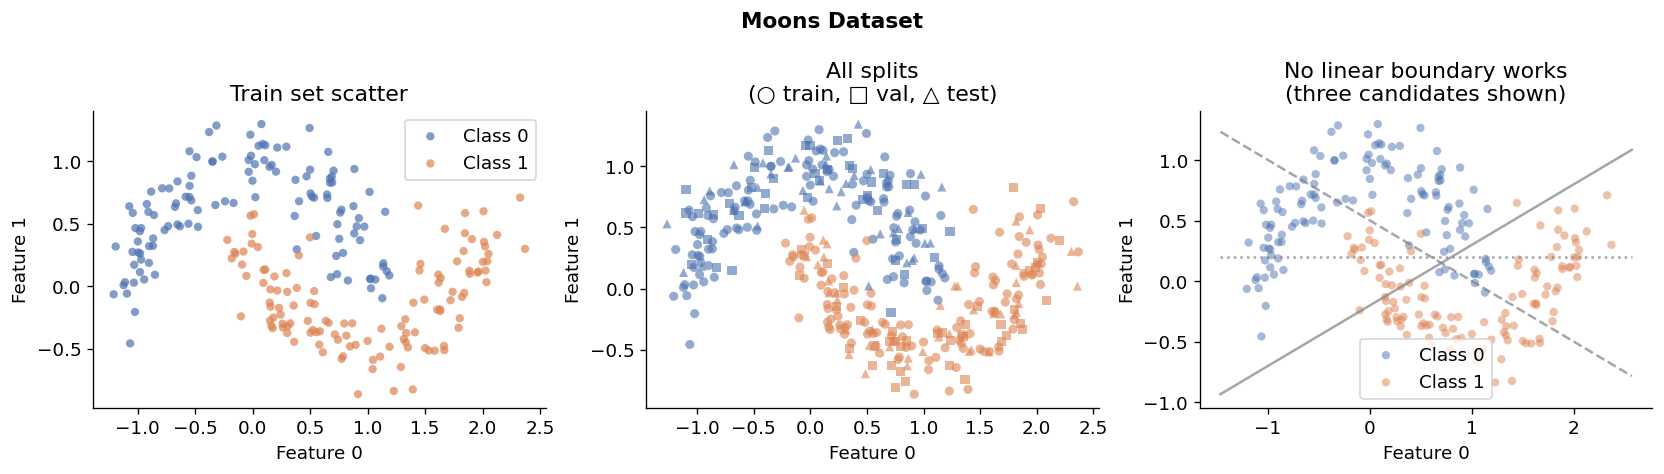

In [18]:
# ── Visualise Moons ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Moons Dataset", fontsize=13, fontweight='bold')

# ── Panel 1: Scatter (train only) ─────────────────────────────────────────
ax = axes[0]
for c in [0, 1]:
    mask = y_tr_m == c
    ax.scatter(X_tr_m[mask, 0], X_tr_m[mask, 1],
               color=colors[c], alpha=0.7, s=25, label=labels[c], edgecolors='none')
ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')
ax.set_title('Train set scatter')
ax.legend()

# ── Panel 2: All splits scatter ───────────────────────────────────────────
ax = axes[1]
for split_X, split_y, marker, size in [
    (X_tr_m, y_tr_m, 'o', 30), (X_val_m, y_val_m, 's', 30), (X_te_m, y_te_m, '^', 30)
]:
    for c in [0, 1]:
        ax.scatter(split_X[split_y==c, 0], split_X[split_y==c, 1],
                   color=colors[c], marker=marker, alpha=0.6, s=size, edgecolors='none')
ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')
ax.set_title('All splits\n(○ train, □ val, △ test)')

# ── Panel 3: Why linear fails — draw a candidate linear boundary ──────────
ax = axes[2]
for c in [0, 1]:
    mask = y_tr_m == c
    ax.scatter(X_tr_m[mask, 0], X_tr_m[mask, 1],
               color=colors[c], alpha=0.5, s=25, label=labels[c], edgecolors='none')
# Draw a few candidate linear boundaries to show they all fail
x_range = np.linspace(X_all_m[:,0].min()-0.2, X_all_m[:,0].max()+0.2, 100)
for slope, intercept, ls in [(-0.5, 0.5, '--'), (0.0, 0.2, ':'), (0.5, -0.2, '-')]:
    ax.plot(x_range, slope*x_range + intercept, ls, color='gray', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Feature 0'); ax.set_ylabel('Feature 1')
ax.set_title('No linear boundary works\n(three candidates shown)')
ax.legend()

plt.tight_layout()
#plt.savefig('../figures/data_inspect_figures/inspect_moons.png', bbox_inches='tight')
plt.show()
#print("Saved → starter_pack/figures/data_inspect_figures/inspect_moons.png")

**Observation:** The two moon-shaped classes heavily overlap in both individual feature ranges.
No straight line can separate them — the boundary needs to curve around each crescent.
This is the geometric reason why a **nonlinear model (with a hidden layer) is expected to win here**.

---
## 3. Digits Dataset

8×8 pixel images of handwritten digits 0–9, flattened to 64-dimensional vectors and scaled to [0,1].
~1797 samples total, fixed train/val/test split provided in `digits_split_indices.npz`.

> **Protocol reminder:** Do NOT apply any additional normalization or feature engineering.

In [19]:
# ── Load ──────────────────────────────────────────────────────────────────────
d   = np.load("../data/digits_data.npz")
sp  = np.load("../data/digits_split_indices.npz")

X_all, y_all = d['X'], d['y']
train_idx, val_idx, test_idx = sp['train_idx'], sp['val_idx'], sp['test_idx']

X_tr_d  = X_all[train_idx];  y_tr_d  = y_all[train_idx]
X_val_d = X_all[val_idx];    y_val_d = y_all[val_idx]
X_te_d  = X_all[test_idx];   y_te_d  = y_all[test_idx]

section("DIGITS — Full Dataset Shapes")
print(f"  Keys in digits_data.npz       : {list(d.files)}")
print(f"  Keys in digits_split_indices  : {list(sp.files)}")
print(f"  X_all shape  : {X_all.shape}   (total_samples, 64_features)")
print(f"  y_all shape  : {y_all.shape}")
print(f"  Feature range: [{X_all.min():.4f}, {X_all.max():.4f}]  ← already in [0,1]")
print(f"  Classes      : {np.unique(y_all).tolist()}  (digits 0–9)")

section("DIGITS — Split Sizes")
total = len(y_all)
print(f"  train: {len(train_idx):4d}  ({100*len(train_idx)/total:.1f}%)")
print(f"  val  : {len(val_idx):4d}  ({100*len(val_idx)/total:.1f}%)")
print(f"  test : {len(test_idx):4d}  ({100*len(test_idx)/total:.1f}%)")
print(f"  total: {total}")

section("DIGITS — Per-Class Sample Counts (train split)")
print("  Class | Count")
print("  ------+------")
for c in range(10):
    n = int((y_tr_d == c).sum())
    bar = '█' * (n // 5)
    print(f"    {c}   |  {n:3d}  {bar}")


  DIGITS — Full Dataset Shapes
  Keys in digits_data.npz       : ['X', 'y']
  Keys in digits_split_indices  : ['train_idx', 'val_idx', 'test_idx']
  X_all shape  : (1797, 64)   (total_samples, 64_features)
  y_all shape  : (1797,)
  Feature range: [0.0000, 1.0000]  ← already in [0,1]
  Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (digits 0–9)

  DIGITS — Split Sizes
  train: 1074  (59.8%)
  val  :  355  (19.8%)
  test :  368  (20.5%)
  total: 1797

  DIGITS — Per-Class Sample Counts (train split)
  Class | Count
  ------+------
    0   |  106  █████████████████████
    1   |  109  █████████████████████
    2   |  106  █████████████████████
    3   |  109  █████████████████████
    4   |  108  █████████████████████
    5   |  109  █████████████████████
    6   |  108  █████████████████████
    7   |  107  █████████████████████
    8   |  104  ████████████████████
    9   |  108  █████████████████████


In [20]:
# ── Feature Statistics (train set) ────────────────────────────────────────────
section("DIGITS — Feature Statistics (train set, all 64 features)")
means  = X_tr_d.mean(axis=0)   # shape (64,)
stds   = X_tr_d.std(axis=0)    # shape (64,)
print(f"  Overall mean of all features : {means.mean():.4f}")
print(f"  Overall std  of all features : {stds.mean():.4f}")
print(f"  Feature with highest mean    : feature {means.argmax()} ({means.max():.4f})")
print(f"  Feature with lowest  mean    : feature {means.argmin()} ({means.min():.4f})")
print(f"  Feature with highest std     : feature {stds.argmax()} ({stds.max():.4f})")
print(f"  Feature with lowest  std     : feature {stds.argmin()} ({stds.min():.4f})")
print(f"\n  Note: features are pixel intensities reshaped from 8x8 images.")
print(f"  Corner pixels (features 0, 7, 56, 63) tend to be near-zero (always blank).")


  DIGITS — Feature Statistics (train set, all 64 features)
  Overall mean of all features : 0.3053
  Overall std  of all features : 0.2303
  Feature with highest mean    : feature 59 (0.7583)
  Feature with lowest  mean    : feature 0 (0.0000)
  Feature with highest std     : feature 42 (0.4072)
  Feature with lowest  std     : feature 0 (0.0000)

  Note: features are pixel intensities reshaped from 8x8 images.
  Corner pixels (features 0, 7, 56, 63) tend to be near-zero (always blank).


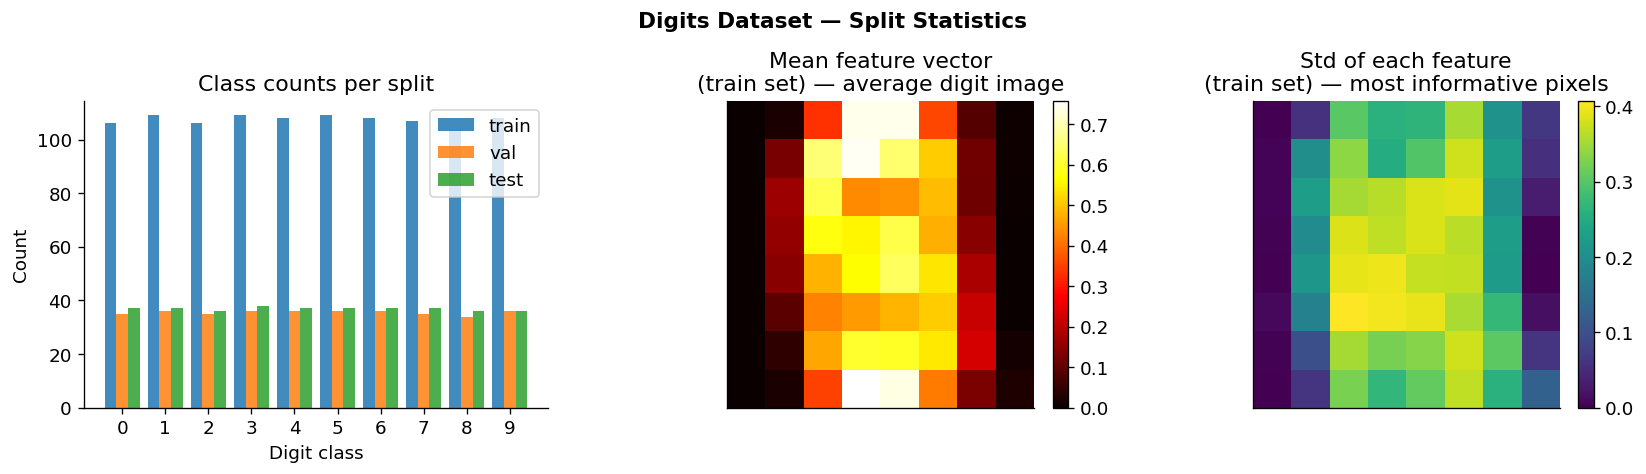

In [21]:
# ── Plot 1: Class distribution bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Digits Dataset — Split Statistics", fontsize=13, fontweight='bold')

# Panel 1: class counts per split
ax = axes[0]
x = np.arange(10)
width = 0.27
for i, (name, y_s) in enumerate([("train", y_tr_d), ("val", y_val_d), ("test", y_te_d)]):
    counts = [(y_s == c).sum() for c in range(10)]
    ax.bar(x + i*width, counts, width, label=name, alpha=0.85)
ax.set_xlabel('Digit class'); ax.set_ylabel('Count')
ax.set_xticks(x + width); ax.set_xticklabels(range(10))
ax.set_title('Class counts per split')
ax.legend()

# Panel 2: mean feature vector reshaped as 8x8 image (average digit image)
ax = axes[1]
avg_image = means.reshape(8, 8)
im = ax.imshow(avg_image, cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Mean feature vector\n(train set) — average digit image')
ax.set_xticks([]); ax.set_yticks([])

# Panel 3: std feature vector as 8x8 image (which pixels vary most?)
ax = axes[2]
std_image = stds.reshape(8, 8)
im = ax.imshow(std_image, cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Std of each feature\n(train set) — most informative pixels')
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
#plt.savefig('../figures/data_inspect_figures/inspect_digits_stats.png', bbox_inches='tight')
plt.show()
#print("Saved → starter_pack/figures/data_inspect_figures/inspect_digits_stats.png")

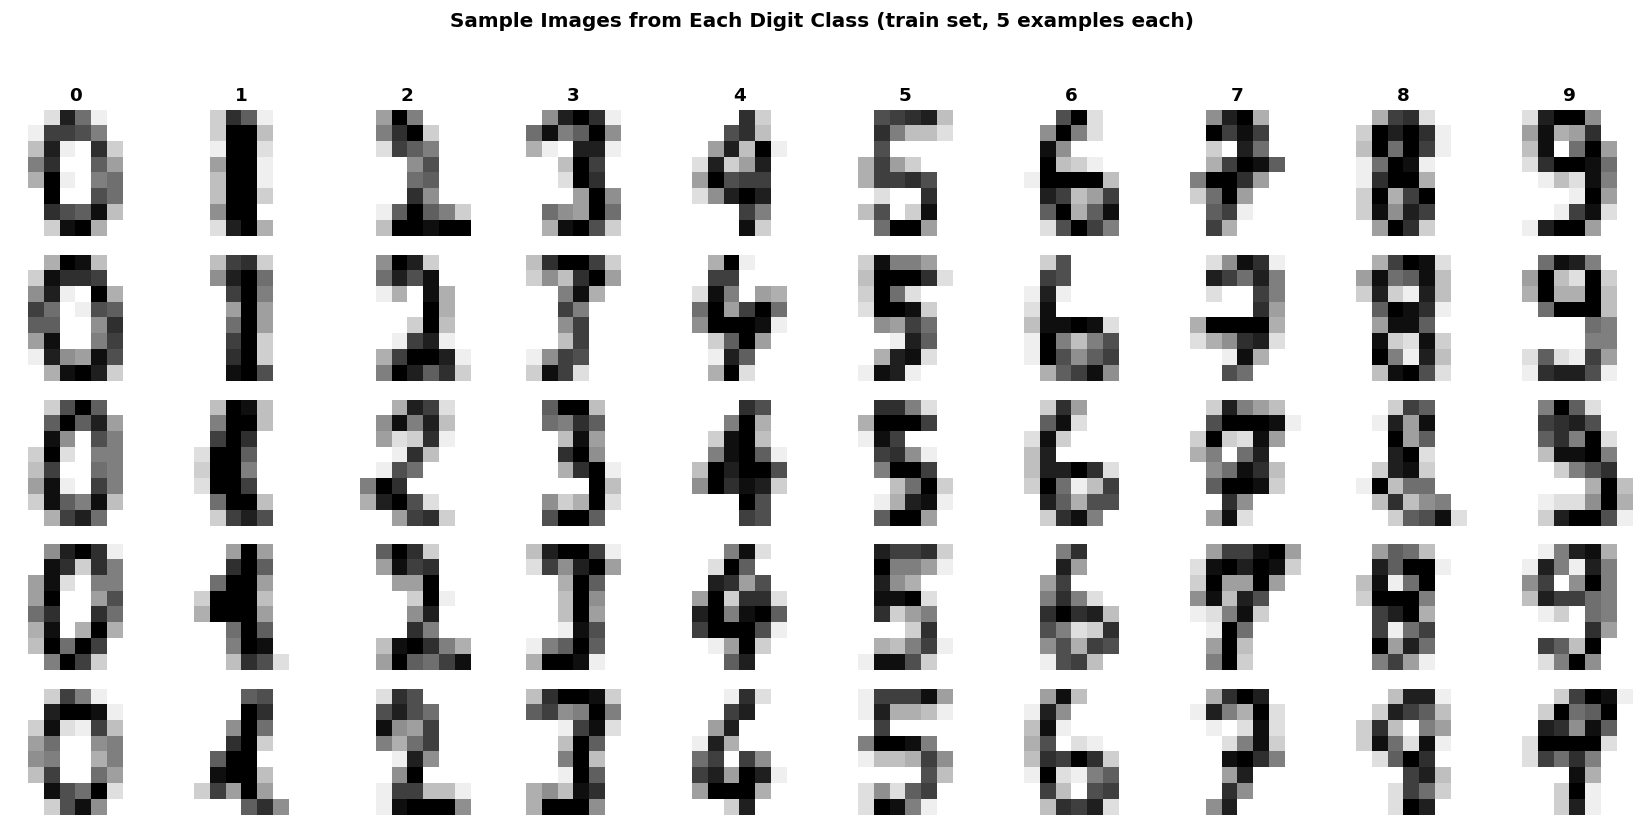

In [22]:
# ── Plot 2: Sample images from each class ─────────────────────────────────────
# Show 5 examples per digit class (10 classes × 5 = 50 images)
n_cols = 10   # one column per digit class
n_rows = 5    # five example images per class

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7))
fig.suptitle("Sample Images from Each Digit Class (train set, 5 examples each)",
             fontsize=12, fontweight='bold')

for col, digit in enumerate(range(10)):
    # Get all training indices for this digit
    idx_class = np.where(y_tr_d == digit)[0]
    # Pick first 5
    for row in range(n_rows):
        ax = axes[row, col]
        img = X_tr_d[idx_class[row]].reshape(8, 8)   # unflatten 64-D → 8×8
        ax.imshow(img, cmap='gray_r', vmin=0, vmax=1, interpolation='nearest')
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig('../figures/data_inspect_figures/inspect_digits_samples.png', bbox_inches='tight')
plt.show()
#print("Saved → starter_pack/figures/data_inspect_figures/inspect_digits_samples.png")

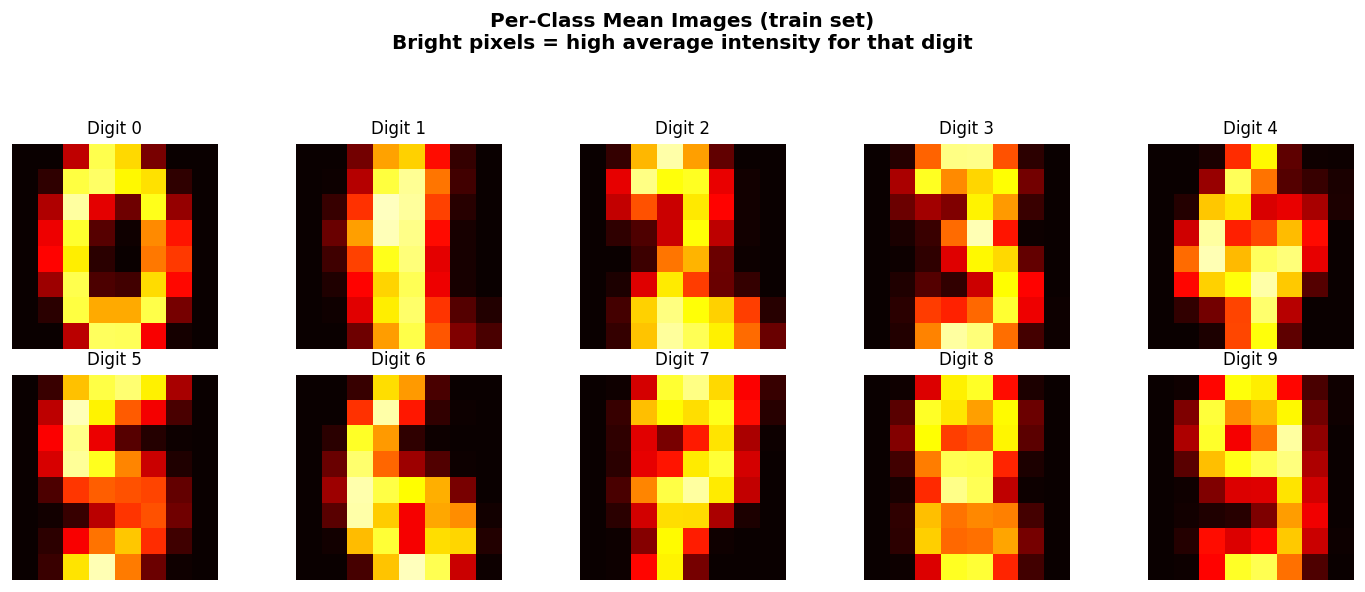

In [23]:
# ── Plot 3: Per-class mean images (the 'average' look of each digit) ───────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Per-Class Mean Images (train set)\n"
             "Bright pixels = high average intensity for that digit",
             fontsize=12, fontweight='bold')

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    class_mean = X_tr_d[y_tr_d == digit].mean(axis=0).reshape(8, 8)
    ax.imshow(class_mean, cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'Digit {digit}', fontsize=10)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.92])
#plt.savefig('../figures/data_inspect_figures/inspect_digits_class_means.png', bbox_inches='tight')
plt.show()
#print("Saved → starter_pack/figures/data_inspect_figures/inspect_digits_class_means.png")

Variance explained by PC1: 15.0%
Variance explained by PC2: 13.6%
Cumulative (PC1+PC2):      28.6%


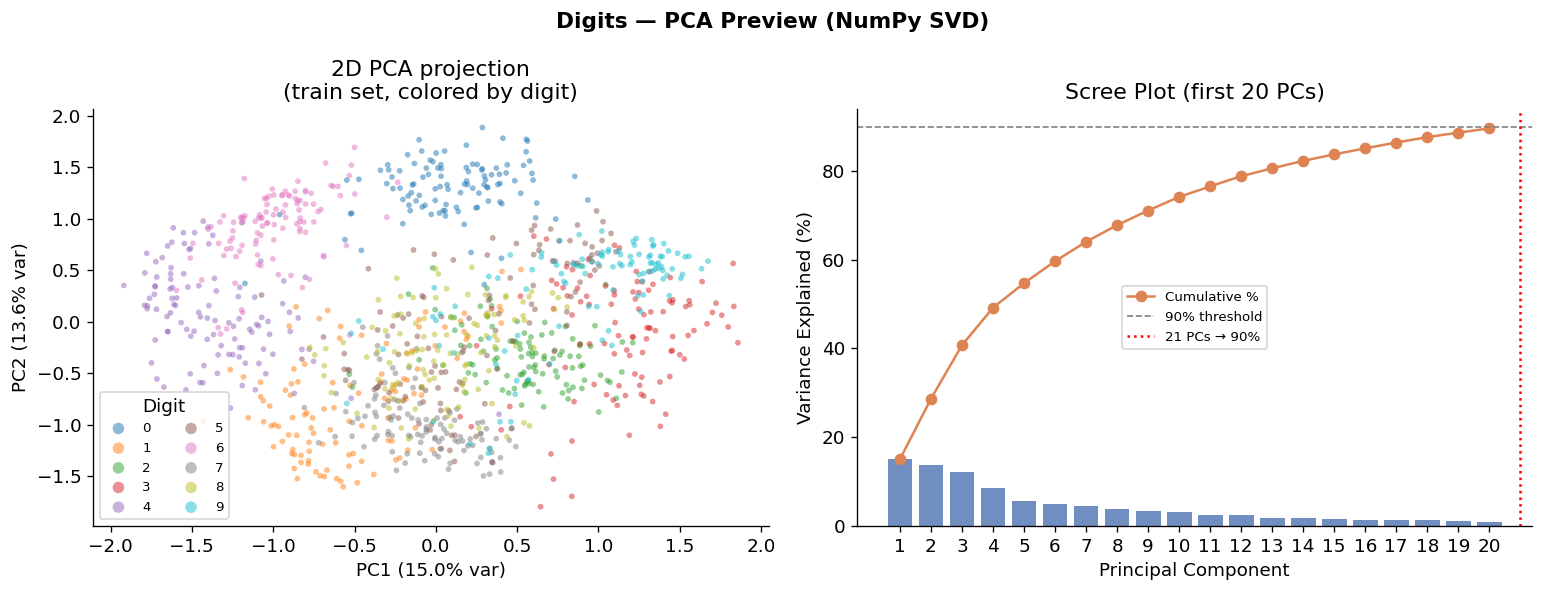


21 principal components explain ≥90% of the variance.


In [24]:
# ── Plot 4: 2D PCA projection (manual, NumPy SVD) ─────────────────────────────
# Purpose here: see if the 10 classes are geometrically separable in 2D.

# Center the training data (subtract mean)
X_centered = X_tr_d - X_tr_d.mean(axis=0)

# SVD: X_centered = U * diag(S) * Vt
# Vt rows are the principal directions (eigenvectors of covariance matrix)
_, S_vals, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Project onto first 2 principal components
X_2d = X_centered @ Vt[:2].T    # shape (n_train, 2)

# Variance explained
var_ratio = S_vals**2 / np.sum(S_vals**2)
print(f"Variance explained by PC1: {var_ratio[0]*100:.1f}%")
print(f"Variance explained by PC2: {var_ratio[1]*100:.1f}%")
print(f"Cumulative (PC1+PC2):      {var_ratio[:2].sum()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Digits — PCA Preview (NumPy SVD)", fontsize=13, fontweight='bold')

# Panel 1: 2D PCA scatter colored by class
ax = axes[0]
cmap = plt.get_cmap('tab10', 10)
for digit in range(10):
    mask = y_tr_d == digit
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=cmap(digit), alpha=0.5, s=12, label=str(digit), edgecolors='none')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.1f}% var)')
ax.set_title('2D PCA projection\n(train set, colored by digit)')
ax.legend(title='Digit', ncol=2, fontsize=8, markerscale=2)

# Panel 2: Scree plot (variance explained per component)
ax = axes[1]
n_components = 20   # show first 20
ax.bar(range(1, n_components+1), var_ratio[:n_components]*100, color='#4C72B0', alpha=0.8)
ax.plot(range(1, n_components+1),
        np.cumsum(var_ratio[:n_components])*100,
        'o-', color='#DD8452', label='Cumulative %')
ax.axhline(90, color='gray', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot (first 20 PCs)')
ax.legend()
ax.set_xticks(range(1, n_components+1))

# Annotate how many PCs needed for 90%
pcs_for_90 = int(np.searchsorted(np.cumsum(var_ratio), 0.90)) + 1
ax.axvline(pcs_for_90, color='red', linestyle=':', linewidth=1.5,
           label=f'{pcs_for_90} PCs → 90%')
ax.legend(fontsize=8)

plt.tight_layout()
#plt.savefig('../figures/data_inspect_figures/inspect_digits_pca.png', bbox_inches='tight')
plt.show()
#print(f"Saved → starter_pack/figures/data_inspect_figures/inspect_digits_pca.png")
print(f"\n{pcs_for_90} principal components explain ≥90% of the variance.")

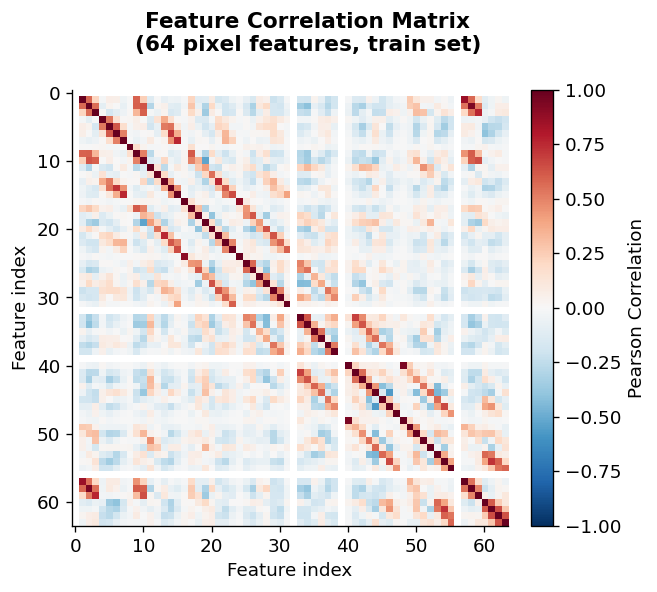

Note: adjacent pixels (spatially close in the 8x8 grid) are strongly correlated.
This is why PCA can compress 64 features significantly with little information loss.


In [25]:
# ── Plot 5: Feature Correlation Matrix ────────────────────────────────────────
# Purpose: See if pixels are redundant (makes PCA effective).

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Feature Correlation Matrix\n(64 pixel features, train set)", 
             fontsize=13, fontweight='bold')

# np.corrcoef expects variables as rows by default, so we set rowvar=False
# We use np.errstate to suppress the visual divide-by-zero RuntimeWarning
# caused by constant pixels (like the black corners in handwritten digits).
with np.errstate(divide='ignore', invalid='ignore'):
    R = np.corrcoef(X_tr_d, rowvar=False)

im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson Correlation')

ax.set_xlabel('Feature index')
ax.set_ylabel('Feature index')

plt.tight_layout()
#plt.savefig('../figures/data_inspect_figures/inspect_digits_corr.png', bbox_inches='tight')
plt.show()
#print(f"Saved → starter_pack/figures/data_inspect_figures/inspect_digits_corr.png\n")
print("Note: adjacent pixels (spatially close in the 8x8 grid) are strongly correlated.")
print("This is why PCA can compress 64 features significantly with little information loss.")


---
## 4. Summary

Run the cell below to print a one-page checklist confirming your data is ready.

In [26]:
section("DATA INSPECTION SUMMARY")

checks = [
    # (description, assertion)
    ("linear_gaussian.npz loaded",           g is not None),
    ("moons.npz loaded",                     m is not None),
    ("digits_data.npz loaded",               d is not None),
    ("digits_split_indices.npz loaded",      sp is not None),
    ("Gaussian X_train shape correct",       X_tr_g.shape == (240, 2)),
    ("Moons X_train shape correct",          X_tr_m.shape == (240, 2)),
    ("Digits X_all shape correct",           X_all.shape == (1797, 64)),
    ("Digits features in [0,1]",             X_all.min() >= 0.0 and X_all.max() <= 1.0),
    ("Digits has 10 classes",                len(np.unique(y_all)) == 10),
    ("Split indices are non-overlapping",    len(set(train_idx) & set(val_idx) & set(test_idx)) == 0),
    ("Split covers full dataset",            len(train_idx)+len(val_idx)+len(test_idx) == len(y_all)),
    ("Gaussian labels are binary",           set(np.unique(y_tr_g)) == {0, 1}),
    ("Moons labels are binary",              set(np.unique(y_tr_m)) == {0, 1}),
]

all_passed = True
for desc, result in checks:
    status = "✓ PASS" if result else "✗ FAIL"
    if not result:
        all_passed = False
    print(f"  {status}  {desc}")

print()
if all_passed:
    print("  ✓ All checks passed. Data is ready — proceed to model implementation.")
else:
    print("  ✗ Some checks FAILED. Re-run scripts/generate_synthetic.py and/or make_digits_split.py.")

print()
print("  Dataset summary:")
print(f"    linear_gaussian : {X_tr_g.shape[0]} train / {X_val_g.shape[0]} val / {X_te_g.shape[0]} test  | d=2, k=2")
print(f"    moons           : {X_tr_m.shape[0]} train / {X_val_m.shape[0]} val / {X_te_m.shape[0]} test  | d=2, k=2")
print(f"    digits          : {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test  | d=64, k=10")


  DATA INSPECTION SUMMARY
  ✓ PASS  linear_gaussian.npz loaded
  ✓ PASS  moons.npz loaded
  ✓ PASS  digits_data.npz loaded
  ✓ PASS  digits_split_indices.npz loaded
  ✓ PASS  Gaussian X_train shape correct
  ✓ PASS  Moons X_train shape correct
  ✓ PASS  Digits X_all shape correct
  ✓ PASS  Digits features in [0,1]
  ✓ PASS  Digits has 10 classes
  ✓ PASS  Split indices are non-overlapping
  ✓ PASS  Split covers full dataset
  ✓ PASS  Gaussian labels are binary
  ✓ PASS  Moons labels are binary

  ✓ All checks passed. Data is ready — proceed to model implementation.

  Dataset summary:
    linear_gaussian : 240 train / 80 val / 80 test  | d=2, k=2
    moons           : 240 train / 80 val / 80 test  | d=2, k=2
    digits          : 1074 train / 355 val / 368 test  | d=64, k=10
